In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r'C:\Users\PC\Downloads\student_info.csv')

In [3]:
df.head()

,student_id,name,gender,age,grade_level,math_score,reading_score,writing_score,attendance_rate,parent_education,study_hours,internet_access,lunch_type,extra_activities,final_result
0,S1,Student_1,Other,17,10,74,61,90,94.660002,Master's,4.120192,Yes,Free or reduced,Yes,Fail
1,S2,Student_2,Male,17,12,99,70,91,93.173227,Bachelor's,2.886505,No,Free or reduced,No,Pass
2,S3,Student_3,Other,17,9,59,60,99,98.631098,PhD,1.909926,No,Free or reduced,No,Fail
3,S4,Student_4,Other,17,12,70,88,69,96.419620,PhD,1.664740,No,Standard,No,Pass
4,S5,Student_5,Male,15,9,85,77,94,91.332105,PhD,2.330918,Yes,Free or reduced,No,Pass


In [4]:
df.isnull().sum()

student_id          0
name                0
gender              0
age                 0
grade_level         0
math_score          0
reading_score       0
writing_score       0
attendance_rate     0
parent_education    0
study_hours         0
internet_access     0
lunch_type          0
extra_activities    0
final_result        0
dtype: int64

In [5]:
print(df.duplicated().sum())

0


In [14]:
df.drop('student_id' , axis=1 , inplace=True)

In [ ]:
df.drop('name' , axis=1 , inplace=True)

In [ ]:
df.head()

,gender,age,grade_level,math_score,reading_score,writing_score,attendance_rate,parent_education,study_hours,internet_access,lunch_type,extra_activities,final_result
0,Other,17,10,74,61,90,94.660002,Master's,4.120192,Yes,Free or reduced,Yes,Fail
1,Male,17,12,99,70,91,93.173227,Bachelor's,2.886505,No,Free or reduced,No,Pass
2,Other,17,9,59,60,99,98.631098,PhD,1.909926,No,Free or reduced,No,Fail
3,Other,17,12,70,88,69,96.419620,PhD,1.664740,No,Standard,No,Pass
4,Male,15,9,85,77,94,91.332105,PhD,2.330918,Yes,Free or reduced,No,Pass


In [43]:
categorical_cols_features = list(df.select_dtypes(include="object").columns)
categorical_cols_features

['gender',
 'parent_education',
 'internet_access',
 'lunch_type',
 'extra_activities',
 'final_result']

In [44]:
df_dummies = pd.get_dummies(df, columns=['gender', 'parent_education','internet_access','lunch_type','extra_activities'], drop_first=True, dtype='uint8')
df_dummies.head()


,age,grade_level,math_score,reading_score,writing_score,attendance_rate,study_hours,final_result,gender_Male,gender_Other,parent_education_High School,parent_education_Master's,parent_education_PhD,internet_access_Yes,lunch_type_Standard,extra_activities_Yes
0,17,10,74,61,90,94.660002,4.120192,Fail,0,1,0,1,0,1,0,1
1,17,12,99,70,91,93.173227,2.886505,Pass,1,0,0,0,0,0,0,0
2,17,9,59,60,99,98.631098,1.909926,Fail,0,1,0,0,1,0,0,0
3,17,12,70,88,69,96.419620,1.664740,Pass,0,1,0,0,1,0,1,0
4,15,9,85,77,94,91.332105,2.330918,Pass,1,0,0,0,1,1,0,0


In [55]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
final_result_encoded = label_encoder.fit_transform(df_dummies['final_result'])


In [ ]:
final_result_encoded = pd.DataFrame(final_result_encoded)
final_result_encoded.head()

,0
0,0
1,1
2,0
3,1
4,1


In [57]:
df_dummies['final_result_encoded'] = final_result_encoded
df_dummies.head()

,age,grade_level,math_score,reading_score,writing_score,attendance_rate,study_hours,final_result,gender_Male,gender_Other,parent_education_High School,parent_education_Master's,parent_education_PhD,internet_access_Yes,lunch_type_Standard,extra_activities_Yes,final_result_encoded
0,17,10,74,61,90,94.660002,4.120192,Fail,0,1,0,1,0,1,0,1,0
1,17,12,99,70,91,93.173227,2.886505,Pass,1,0,0,0,0,0,0,0,1
2,17,9,59,60,99,98.631098,1.909926,Fail,0,1,0,0,1,0,0,0,0
3,17,12,70,88,69,96.419620,1.664740,Pass,0,1,0,0,1,0,1,0,1
4,15,9,85,77,94,91.332105,2.330918,Pass,1,0,0,0,1,1,0,0,1


In [58]:
df_encoded = df_dummies.drop('final_result', axis=1)
df_encoded.head()

,age,grade_level,math_score,reading_score,writing_score,attendance_rate,study_hours,gender_Male,gender_Other,parent_education_High School,parent_education_Master's,parent_education_PhD,internet_access_Yes,lunch_type_Standard,extra_activities_Yes,final_result_encoded
0,17,10,74,61,90,94.660002,4.120192,0,1,0,1,0,1,0,1,0
1,17,12,99,70,91,93.173227,2.886505,1,0,0,0,0,0,0,0,1
2,17,9,59,60,99,98.631098,1.909926,0,1,0,0,1,0,0,0,0
3,17,12,70,88,69,96.419620,1.664740,0,1,0,0,1,0,1,0,1
4,15,9,85,77,94,91.332105,2.330918,1,0,0,0,1,1,0,0,1


In [59]:
def detect_iqr_outliers(dataframe, column):
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = dataframe[(dataframe[column] < lower_bound) | (dataframe[column] > upper_bound)]
    return outliers

In [60]:
age_outliers_iqr = detect_iqr_outliers(df_encoded, 'age')

print("Age Outliers based on IQR:")
age_outliers_iqr

Age Outliers based on IQR:


,age,grade_level,math_score,reading_score,writing_score,attendance_rate,study_hours,gender_Male,gender_Other,parent_education_High School,parent_education_Master's,parent_education_PhD,internet_access_Yes,lunch_type_Standard,extra_activities_Yes,final_result_encoded


In [61]:
grade_level_outliers_iqr = detect_iqr_outliers(df_encoded, 'grade_level')

print("grade level Outliers based on IQR:")
grade_level_outliers_iqr

grade level Outliers based on IQR:


,age,grade_level,math_score,reading_score,writing_score,attendance_rate,study_hours,gender_Male,gender_Other,parent_education_High School,parent_education_Master's,parent_education_PhD,internet_access_Yes,lunch_type_Standard,extra_activities_Yes,final_result_encoded


In [62]:
math_score_outliers_iqr = detect_iqr_outliers(df_encoded, 'math_score')

print("math_score Outliers based on IQR:")
math_score_outliers_iqr

math_score Outliers based on IQR:


,age,grade_level,math_score,reading_score,writing_score,attendance_rate,study_hours,gender_Male,gender_Other,parent_education_High School,parent_education_Master's,parent_education_PhD,internet_access_Yes,lunch_type_Standard,extra_activities_Yes,final_result_encoded


In [63]:
reading_score_outliers_iqr = detect_iqr_outliers(df_encoded, 'reading_score')

print("reading_score Outliers based on IQR:")
reading_score_outliers_iqr

reading_score Outliers based on IQR:


,age,grade_level,math_score,reading_score,writing_score,attendance_rate,study_hours,gender_Male,gender_Other,parent_education_High School,parent_education_Master's,parent_education_PhD,internet_access_Yes,lunch_type_Standard,extra_activities_Yes,final_result_encoded


In [64]:
attendance_rate_outliers_iqr = detect_iqr_outliers(df_encoded, 'attendance_rate')

print("attendance_rate Outliers based on IQR:")
attendance_rate_outliers_iqr

attendance_rate Outliers based on IQR:


,age,grade_level,math_score,reading_score,writing_score,attendance_rate,study_hours,gender_Male,gender_Other,parent_education_High School,parent_education_Master's,parent_education_PhD,internet_access_Yes,lunch_type_Standard,extra_activities_Yes,final_result_encoded


In [65]:
study_hours_outliers_iqr = detect_iqr_outliers(df_encoded, 'study_hours')

print("study_hours Outliers based on IQR:")
study_hours_outliers_iqr

study_hours Outliers based on IQR:


,age,grade_level,math_score,reading_score,writing_score,attendance_rate,study_hours,gender_Male,gender_Other,parent_education_High School,parent_education_Master's,parent_education_PhD,internet_access_Yes,lunch_type_Standard,extra_activities_Yes,final_result_encoded


In [67]:
x = df_encoded.drop(['final_result_encoded'], axis=1) 
y = df_dummies['final_result_encoded'] # labels
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42) 

In [68]:
x_train.head()

,age,grade_level,math_score,reading_score,writing_score,attendance_rate,study_hours,gender_Male,gender_Other,parent_education_High School,parent_education_Master's,parent_education_PhD,internet_access_Yes,lunch_type_Standard,extra_activities_Yes
541,17,10,57,73,99,99.418805,1.280275,0,0,0,1,0,0,0,1
440,16,12,77,77,76,84.674816,4.782860,0,0,1,0,0,1,0,0
482,15,11,78,55,92,93.162044,2.531334,0,0,1,0,0,1,1,1
422,15,10,89,90,89,83.732799,2.237850,1,0,0,0,1,0,0,0
778,15,9,72,64,99,80.402757,4.801117,0,1,1,0,0,0,0,1


In [69]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

numerical_features = ['age', 'grade_level', 'math_score', 'reading_score', 'writing_score','attendance_rate','study_hours']
x_train_scaled = scaler.fit_transform(x_train[numerical_features])

In [71]:
x_train_scaled = pd.DataFrame(x_train_scaled, columns=numerical_features)
x_train_scaled.head()

,age,grade_level,math_score,reading_score,writing_score,attendance_rate,study_hours
0,1.251405,-0.425959,-1.283684,-0.067862,1.659429,1.711230,-1.508472
1,0.017625,1.333164,0.128621,0.216590,0.056549,-0.869735,1.513928
2,-1.216154,0.453602,0.199236,-1.347895,1.171596,0.615971,-0.428927
3,-1.216154,-0.425959,0.976004,1.141058,0.962524,-1.034637,-0.682175
4,-1.216154,-1.305521,-0.224456,-0.707879,1.659429,-1.617568,1.529682


In [72]:
non_scaled_features = x_train.drop(columns=numerical_features, axis=1)
non_scaled_features.head()

,gender_Male,gender_Other,parent_education_High School,parent_education_Master's,parent_education_PhD,internet_access_Yes,lunch_type_Standard,extra_activities_Yes
541,0,0,0,1,0,0,0,1
440,0,0,1,0,0,1,0,0
482,0,0,1,0,0,1,1,1
422,1,0,0,0,1,0,0,0
778,0,1,1,0,0,0,0,1


In [73]:
non_scaled_features.reset_index(inplace=True)

In [74]:
final_X_train = pd.concat([x_train_scaled , non_scaled_features], axis=1)
final_X_train.head()

,age,grade_level,math_score,reading_score,writing_score,attendance_rate,study_hours,index,gender_Male,gender_Other,parent_education_High School,parent_education_Master's,parent_education_PhD,internet_access_Yes,lunch_type_Standard,extra_activities_Yes
0,1.251405,-0.425959,-1.283684,-0.067862,1.659429,1.711230,-1.508472,541,0,0,0,1,0,0,0,1
1,0.017625,1.333164,0.128621,0.216590,0.056549,-0.869735,1.513928,440,0,0,1,0,0,1,0,0
2,-1.216154,0.453602,0.199236,-1.347895,1.171596,0.615971,-0.428927,482,0,0,1,0,0,1,1,1
3,-1.216154,-0.425959,0.976004,1.141058,0.962524,-1.034637,-0.682175,422,1,0,0,0,1,0,0,0
4,-1.216154,-1.305521,-0.224456,-0.707879,1.659429,-1.617568,1.529682,778,0,1,1,0,0,0,0,1


In [75]:
x_test_scaled = scaler.fit_transform(x_test[numerical_features])


In [77]:
x_test_scaled = pd.DataFrame(x_test_scaled, columns=numerical_features)
x_test_scaled.head()

,age,grade_level,math_score,reading_score,writing_score,attendance_rate,study_hours
0,-1.240784,0.488989,1.222954,-0.612589,-0.073217,-0.438690,0.127190
1,-1.240784,-1.278441,0.743812,-0.073061,-1.247458,-1.216402,1.148511
2,-1.240784,-0.394726,-0.625167,0.803672,0.410293,0.365187,0.123775
3,-1.240784,-0.394726,-0.967411,-1.691645,-1.661896,1.405225,1.774307
4,-0.036139,1.372704,0.127771,0.938554,-0.349509,-1.360794,-1.090430


In [78]:
non_scaled_features2 = x_test.drop(columns=numerical_features, axis=1)
non_scaled_features2.head()

,gender_Male,gender_Other,parent_education_High School,parent_education_Master's,parent_education_PhD,internet_access_Yes,lunch_type_Standard,extra_activities_Yes
521,1,0,0,0,0,0,1,1
737,1,0,0,1,0,1,1,1
740,0,0,0,0,1,1,0,0
660,0,1,0,0,0,1,0,1
411,0,0,0,0,1,0,0,1


In [79]:
non_scaled_features2.reset_index(inplace=True)

In [80]:
final_X_test = pd.concat([x_test_scaled , non_scaled_features2], axis=1)
final_X_test.head()

,age,grade_level,math_score,reading_score,writing_score,attendance_rate,study_hours,index,gender_Male,gender_Other,parent_education_High School,parent_education_Master's,parent_education_PhD,internet_access_Yes,lunch_type_Standard,extra_activities_Yes
0,-1.240784,0.488989,1.222954,-0.612589,-0.073217,-0.438690,0.127190,521,1,0,0,0,0,0,1,1
1,-1.240784,-1.278441,0.743812,-0.073061,-1.247458,-1.216402,1.148511,737,1,0,0,1,0,1,1,1
2,-1.240784,-0.394726,-0.625167,0.803672,0.410293,0.365187,0.123775,740,0,0,0,0,1,1,0,0
3,-1.240784,-0.394726,-0.967411,-1.691645,-1.661896,1.405225,1.774307,660,0,1,0,0,0,1,0,1
4,-0.036139,1.372704,0.127771,0.938554,-0.349509,-1.360794,-1.090430,411,0,0,0,0,1,0,0,1


In [81]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [84]:
Knn_Predictions = knn.predict(x_test)
Knn_Predictions

array([1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1,
       0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1,
       0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1,
       0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0,
       1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0,
       0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1])

In [85]:
pd.DataFrame(Knn_Predictions).value_counts()

0
1    156
0    144
Name: count, dtype: int64

In [86]:
pd.DataFrame(y_test).value_counts()

final_result_encoded
1                       160
0                       140
Name: count, dtype: int64

In [87]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, Knn_Predictions))

[[ 84  56]
 [ 60 100]]


In [88]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, Knn_Predictions)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.61


In [89]:
from sklearn.metrics import classification_report
print(classification_report(y_test, Knn_Predictions))

              precision    recall  f1-score   support

           0       0.58      0.60      0.59       140
           1       0.64      0.62      0.63       160

    accuracy                           0.61       300
   macro avg       0.61      0.61      0.61       300
weighted avg       0.61      0.61      0.61       300



<Axes: xlabel='final_result_encoded'>

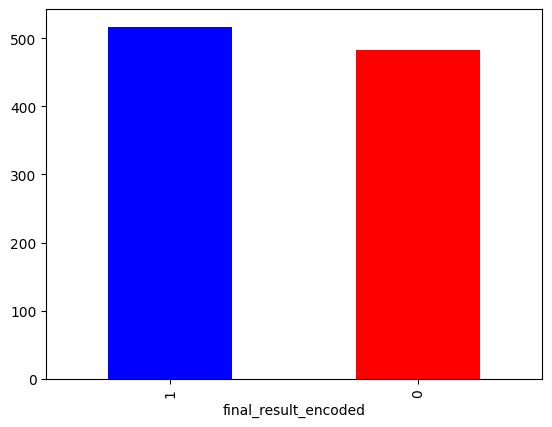

In [90]:
df_encoded['final_result_encoded'].value_counts().plot(kind = 'bar', color = ['blue', 'red'])

In [91]:
# Percentage for each class
class_percentage = df_encoded['final_result_encoded'].value_counts(normalize=True) * 100
print(class_percentage)


final_result_encoded
1    51.7
0    48.3
Name: proportion, dtype: float64
